<a href="https://colab.research.google.com/github/DreanoLucas/ML_AIR_Attack/blob/main/KDD_Kamarul_FINAL_complete2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NSL-KDD Intrusion Detection — FINAL Complete Notebook (Exploration → Day 6)

**Author: Kamarul.** The complete project in one place: the **full data exploration & preprocessing** (mirroring `02_KDD_exploration_and_preprocessing`), then **every graphic from Days 2–6**, each with *what it shows, why we did it, and what it means*. Trained on the **full dataset**.

### Data protocol (read this once)
* This notebook **trains/explores on the full `KDDTrain+.txt`** if you upload it. If only the 20% subset is present it falls back to that (with a note).
* The honest final result is measured on the **separate `KDDTest+.txt`**.
* **Golden rule:** train and test must never share rows. The 20% file is a *subset* of the full train file, so never "train full / test 20%" — that leaks. `KDDTrain` pairs with `KDDTest`.

**Upload `KDDTrain+.txt` (full) — or `KDDTrain__20Percent.txt` — and `KDDTest_.txt` first.** Runs in a few minutes (longer on the full file).

## 0. Libraries and helper functions

In [1]:
import pandas as pd, numpy as np, math, warnings, os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, mean_squared_error,
                             classification_report, ConfusionMatrixDisplay)
pd.set_option('display.max_columns', 60); plt.rcParams['figure.figsize']=(8,4); plt.rcParams['figure.dpi']=90

# --- helpers reproduced from the course / 02 notebook ---
def rotate_labels(sm, x_rot=90, y_rot=0):
    for ax in sm.ravel():
        ax.set_xlabel(ax.get_xlabel(), rotation=x_rot)
        ax.set_ylabel(ax.get_ylabel(), rotation=y_rot, ha='right', va='center')
def plot_corr(frame, width=10, height=10, print_value=False):
    corr=frame.corr(numeric_only=True)
    fig,ax=plt.subplots(figsize=(width,height))
    im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm')
    ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns,rotation=90,fontsize=7)
    ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns,fontsize=7)
    fig.colorbar(im,shrink=0.7); plt.tight_layout(); plt.show()
def get_features_correlated_to_target(frame, target_feature):
    corr=frame.corr(numeric_only=True)[target_feature].drop(target_feature)
    return corr.abs().sort_values(ascending=False)

## 1. Load the data (full dataset preferred)

In [2]:
COL_NAMES = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level']
attack_category = {
    'neptune':'DoS','smurf':'DoS','back':'DoS','teardrop':'DoS','pod':'DoS','land':'DoS',
    'apache2':'DoS','processtable':'DoS','mailbomb':'DoS','udpstorm':'DoS','worm':'DoS',
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','mscan':'Probe','saint':'Probe',
    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','phf':'R2L','multihop':'R2L','warezmaster':'R2L',
    'warezclient':'R2L','spy':'R2L','xlock':'R2L','xsnoop':'R2L','snmpguess':'R2L','snmpgetattack':'R2L',
    'httptunnel':'R2L','sendmail':'R2L','named':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','rootkit':'U2R','perl':'U2R','sqlattack':'U2R',
    'xterm':'U2R','ps':'U2R'}
def _resolve_train():
    fs=[f for f in sorted(os.listdir('.')) if f.lower().endswith(('.txt','.csv'))]
    full=[f for f in fs if 'train' in f.lower() and '20' not in f.lower() and 'percent' not in f.lower()]
    if full: print('Using FULL training set:', full[0]); return full[0]
    sub=[f for f in fs if 'train' in f.lower()]
    if sub:
        print('NOTE: full KDDTrain+.txt not found -> using the 20% subset:', sub[0])
        print('      Upload KDDTrain+.txt (the ~126k-row file) to use the FULL dataset.')
        return sub[0]
    from google.colab import files as gf; up=gf.upload()
    for f in up:
        if 'train' in f.lower(): return f
    return list(up.keys())[0]
def _resolve_test():
    fs=[f for f in sorted(os.listdir('.')) if f.lower().endswith(('.txt','.csv'))]
    t=[f for f in fs if 'test' in f.lower()]
    if t: return t[0]
    from google.colab import files as gf; up=gf.upload()
    for f in up:
        if 'test' in f.lower(): return f
    return list(up.keys())[0]
def load(path):
    has_header=open(path).readline().lower().startswith('duration')
    d=pd.read_csv(path, header=0 if has_header else None); d.columns=COL_NAMES
    d['is_attack']=(d['attack']!='normal').astype(int)
    d['category']=d['attack'].apply(lambda a:'normal' if a=='normal' else attack_category.get(a,'unknown'))
    for c in ['duration','src_bytes','dst_bytes','count','srv_count','dst_host_count','dst_host_srv_count']:
        d[c+'_log']=np.log1p(d[c])
    return d
df=load(_resolve_train())
df_test_official=load(_resolve_test())
# feature lists used for modelling (Days 2-6)
BASE=['same_srv_rate','src_bytes_log','dst_bytes_log','dst_host_srv_count','logged_in',
      'serror_rate','diff_srv_rate','count_log','dst_host_same_srv_rate','srv_count_log']
CONTENT=['hot','num_failed_logins','num_compromised','root_shell','su_attempted',
         'num_root','num_file_creations','num_shells','num_access_files','is_guest_login']
FEATURES=BASE+CONTENT
dtr,dte=train_test_split(df,test_size=0.3,random_state=19,stratify=df['is_attack'])
ytr,yte=dtr['is_attack'].values,dte['is_attack'].values
dtr_c,dte_c=train_test_split(df,test_size=0.3,random_state=19,stratify=df['category'])
ytr_c,yte_c=dtr_c['category'].values,dte_c['category'].values
# a sample for the heavy visual plots (keeps them fast & readable on the full 126k set)
df_viz=df.sample(min(25000,len(df)), random_state=0)
print('\nloaded training rows:', len(df), '| official test rows:', len(df_test_official))

Saving KDDTest+.txt to KDDTest+.txt

loaded training rows: 22544 | official test rows: 22544


# Part 1 — Data exploration (from `02_KDD_exploration_and_preprocessing`)

We **look before we model**: the shape of the data, the class balance, skew, which features separate attacks, the correlation structure, and the all-important **log transform**. Every preprocessing choice the later days rely on is justified here.

### 1.1 First look — structure and columns

In [3]:
display(df.head(8))
df.info(verbose=False)
print('\nattack types:', df['attack'].unique()[:12], '...')
print('protocols   :', df['protocol_type'].unique())
print('flags       :', df['flag'].unique())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level,is_attack,category,duration_log,src_bytes_log,dst_bytes_log,count_log,srv_count_log,dst_host_count_log,dst_host_srv_count_log
0,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,229,10,0.0,0.00,1.0,1.0,0.04,0.06,0.00,255,10,0.04,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21,1,DoS,0.000000,0.000000,0.000000,5.438079,2.397895,5.545177,2.397895
1,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,136,1,0.0,0.00,1.0,1.0,0.01,0.06,0.00,255,1,0.00,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21,1,DoS,0.000000,0.000000,0.000000,4.919981,0.693147,5.545177,0.693147
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.00,0.0,0.0,1.00,0.00,0.00,134,86,0.61,0.04,0.61,0.02,0.00,0.00,0.00,0.00,normal,21,0,normal,1.098612,9.471473,0.000000,0.693147,0.693147,4.905275,4.465908
3,0,icmp,eco_i,SF,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,65,0.0,0.00,0.0,0.0,1.00,0.00,1.00,3,57,1.00,0.00,1.00,0.28,0.00,0.00,0.00,0.00,saint,15,1,Probe,0.000000,3.044522,0.000000,0.693147,4.189655,1.386294,4.060443
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,0.0,0.12,1.0,0.5,1.00,0.00,0.75,29,86,0.31,0.17,0.03,0.02,0.00,0.00,0.83,0.71,mscan,11,1,Probe,0.693147,0.000000,2.772589,0.693147,2.197225,3.401197,4.465908
5,0,tcp,http,SF,267,14515,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,4,4,0.0,0.00,0.0,0.0,1.00,0.00,0.00,155,255,1.00,0.00,0.01,0.03,0.01,0.00,0.00,0.00,normal,21,0,normal,0.000000,5.590987,9.583007,1.609438,1.609438,5.049856,5.545177
6,0,tcp,smtp,SF,1022,387,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,3,0.0,0.00,0.0,0.0,1.00,0.00,1.00,255,28,0.11,0.72,0.00,0.00,0.00,0.00,0.72,0.04,normal,21,0,normal,0.000000,6.930495,5.961005,0.693147,1.386294,5.545177,3.367296
7,0,tcp,telnet,SF,129,174,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.00,0.0,0.0,1.00,0.00,0.00,255,255,1.00,0.00,0.00,0.00,0.01,0.01,0.02,0.02,guess_passwd,15,1,R2L,0.000000,4.867534,5.164786,0.693147,0.693147,5.545177,5.545177


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Columns: 52 entries, duration to dst_host_srv_count_log
dtypes: float64(22), int64(25), object(5)
memory usage: 8.9+ MB

attack types: ['neptune' 'normal' 'saint' 'mscan' 'guess_passwd' 'smurf' 'apache2'
 'satan' 'buffer_overflow' 'back' 'warezmaster' 'snmpgetattack'] ...
protocols   : ['tcp' 'icmp' 'udp']
flags       : ['REJ' 'SF' 'RSTO' 'S0' 'RSTR' 'SH' 'S3' 'S2' 'S1' 'RSTOS0' 'OTH']


**Reading:** each row is one connection: basic TCP info (`duration`, `protocol_type`, `service`, `flag`, byte counts), content features (`hot`, `logged_in`, `root_shell`…), and time-window traffic statistics (`count`, `serror_rate`, `same_srv_rate`…). There are **no missing values** in NSL-KDD, which simplifies cleaning.

### 1.2 The labels and their balance — the central difficulty

Binary balance (%):
is_attack
1    56.9
0    43.1
Name: proportion, dtype: float64

By category:
category
normal    9711
DoS       7460
R2L       2885
Probe     2421
U2R         67
Name: count, dtype: int64


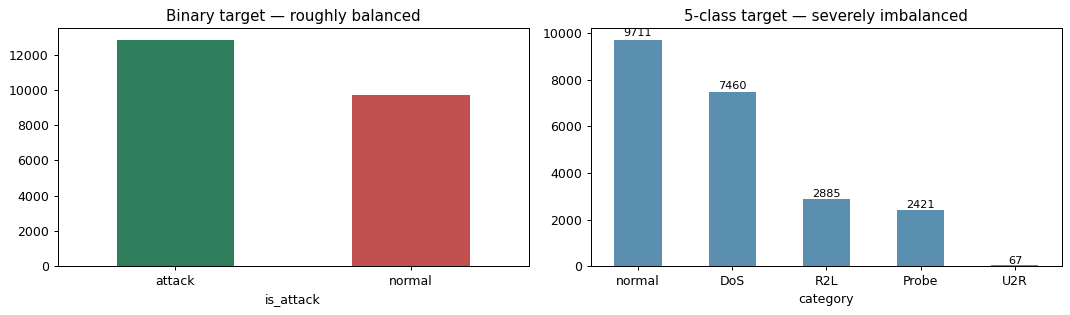

In [4]:
print('Binary balance (%):'); print((df['is_attack'].value_counts(normalize=True)*100).round(1))
print('\nBy category:'); print(df['category'].value_counts())
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
df['is_attack'].map({0:'normal',1:'attack'}).value_counts().plot.bar(ax=ax[0], color=['#2E7D5B','#C0504D'])
ax[0].set_title('Binary target — roughly balanced'); ax[0].tick_params(axis='x', rotation=0)
df['category'].value_counts().plot.bar(ax=ax[1], color='#5B8FB0'); ax[1].set_title('5-class target — severely imbalanced'); ax[1].tick_params(axis='x', rotation=0)
for i,v in enumerate(df['category'].value_counts()): ax[1].text(i, v+v*0.01+50, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**Reading — the villain of the project.** Binary is ~53% normal / 47% attack (easy). The 5-class target is brutally imbalanced: `DoS` is huge while `U2R` has only a handful and `R2L` a few hundred. This imbalance is why the rare attacks (R2L, U2R) are so hard, and it drives everything we do later (SMOTE, class weights, thresholds).

### 1.3 Basic statistics and the skew problem (boxplot)

        src_bytes  dst_bytes    count  duration
count     22544.0    22544.0  22544.0   22544.0
mean      10395.5     2056.0     79.0     218.9
std      472786.4    21219.3    128.5    1407.2
min           0.0        0.0      0.0       0.0
25%           0.0        0.0      1.0       0.0
50%          54.0       46.0      8.0       0.0
75%         287.0      601.0    123.2       0.0
max    62825648.0  1345927.0    511.0   57715.0

src_bytes: mean=10395.5  var=223527009421.0  std=472786.4  skew=117.5


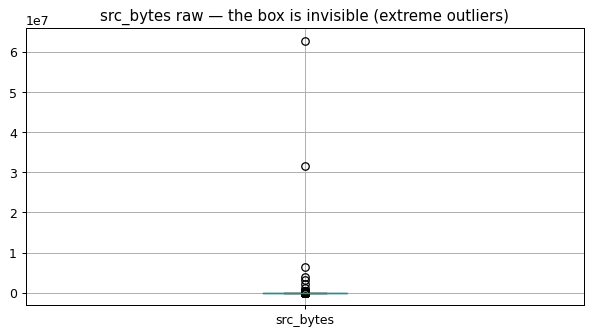

In [5]:
print(df[['src_bytes','dst_bytes','count','duration']].describe().round(1))
x=df['src_bytes']; print('\nsrc_bytes: mean=%.1f  var=%.1f  std=%.1f  skew=%.1f'%(x.mean(),x.var(),x.std(),x.skew()))
df.boxplot(column=['src_bytes']); plt.title('src_bytes raw — the box is invisible (extreme outliers)'); plt.show()

**Reading:** `src_bytes` ranges from 0 to millions with a skew of ~150 — a handful of giant connections squash everything else into a single line. A feature shaped like this is useless to a model until we transform it (1.7).

### 1.4 Do features separate the classes? (boxplots by class)

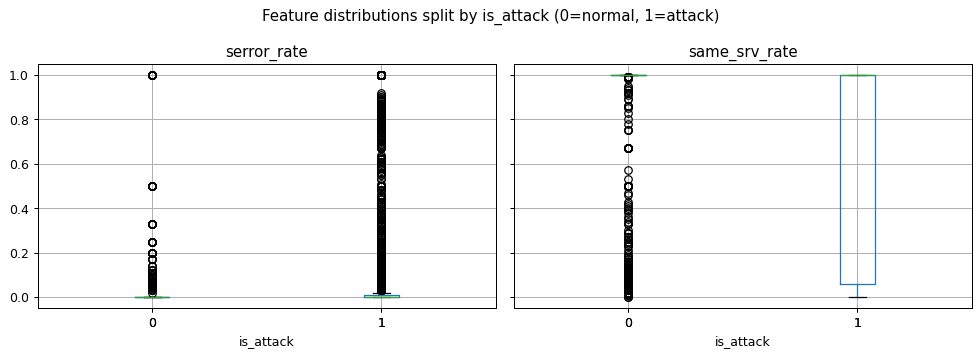

In [6]:
df.boxplot(column=['serror_rate','same_srv_rate'], by='is_attack', figsize=(11,4))
plt.suptitle('Feature distributions split by is_attack (0=normal, 1=attack)'); plt.tight_layout(); plt.show()

**Reading:** where the normal box and the attack box **barely overlap**, the feature separates the classes well. `serror_rate` and `same_srv_rate` do exactly that — promising predictors the models will lean on.

### 1.5 Histograms — distributions, binning, and by-class shape

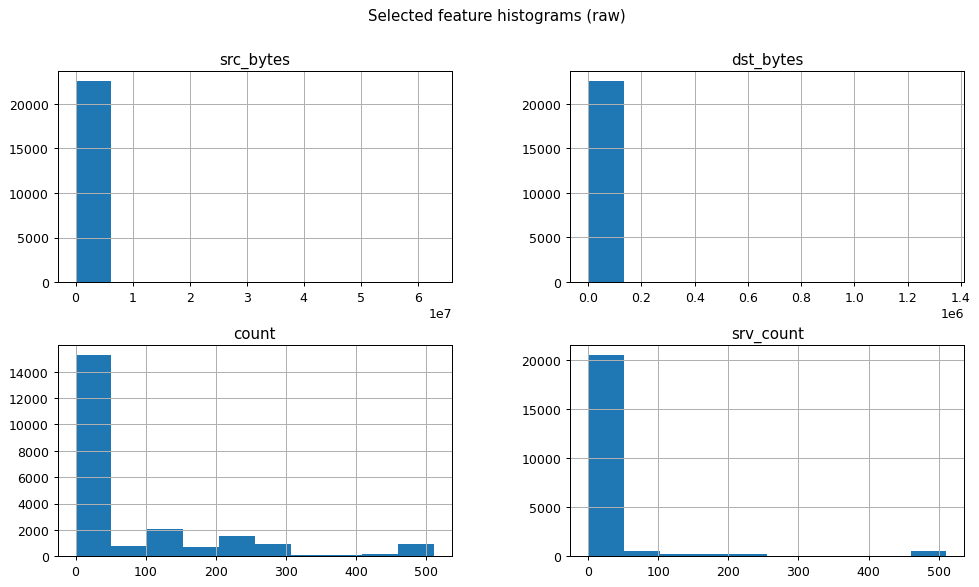

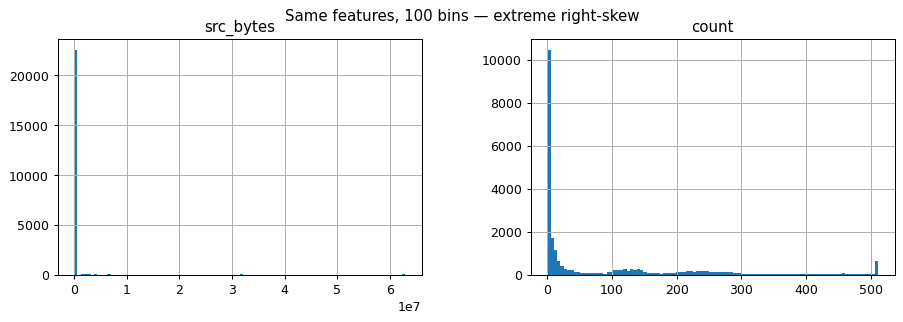

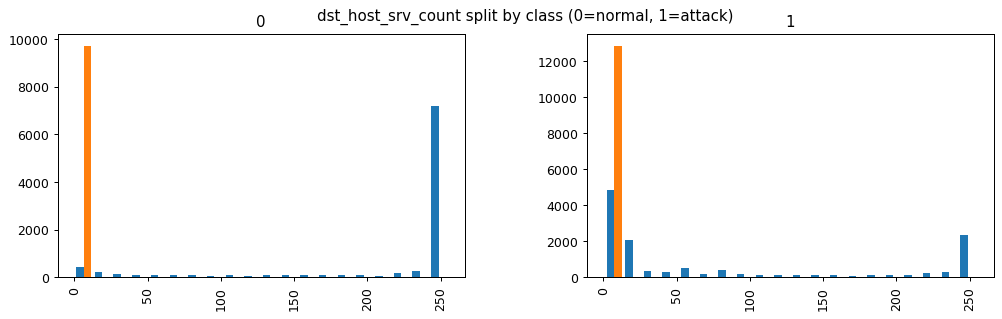

In [7]:
df_viz[['src_bytes','dst_bytes','count','srv_count']].hist(figsize=(13,7)); plt.suptitle('Selected feature histograms (raw)'); plt.show()
fig=df_viz[['src_bytes','count']].hist(bins=100, figsize=(12,3.4)); plt.suptitle('Same features, 100 bins — extreme right-skew'); plt.show()
df_viz[['dst_host_srv_count','is_attack']].hist(figsize=(13,3.6), by='is_attack', sharex=True, bins=20, layout=(1,2))
plt.suptitle('dst_host_srv_count split by class (0=normal, 1=attack)'); plt.show()

**Reading:** the raw magnitude features are spikes at 0 with a long thin tail (right-skew) — confirming the need for the log transform. The by-class histogram shows `dst_host_srv_count` concentrates at **high** values for normal traffic and spreads to **low** values for attacks — a genuinely informative feature.

### 1.6 Correlation structure (scatter-matrix + heatmap)

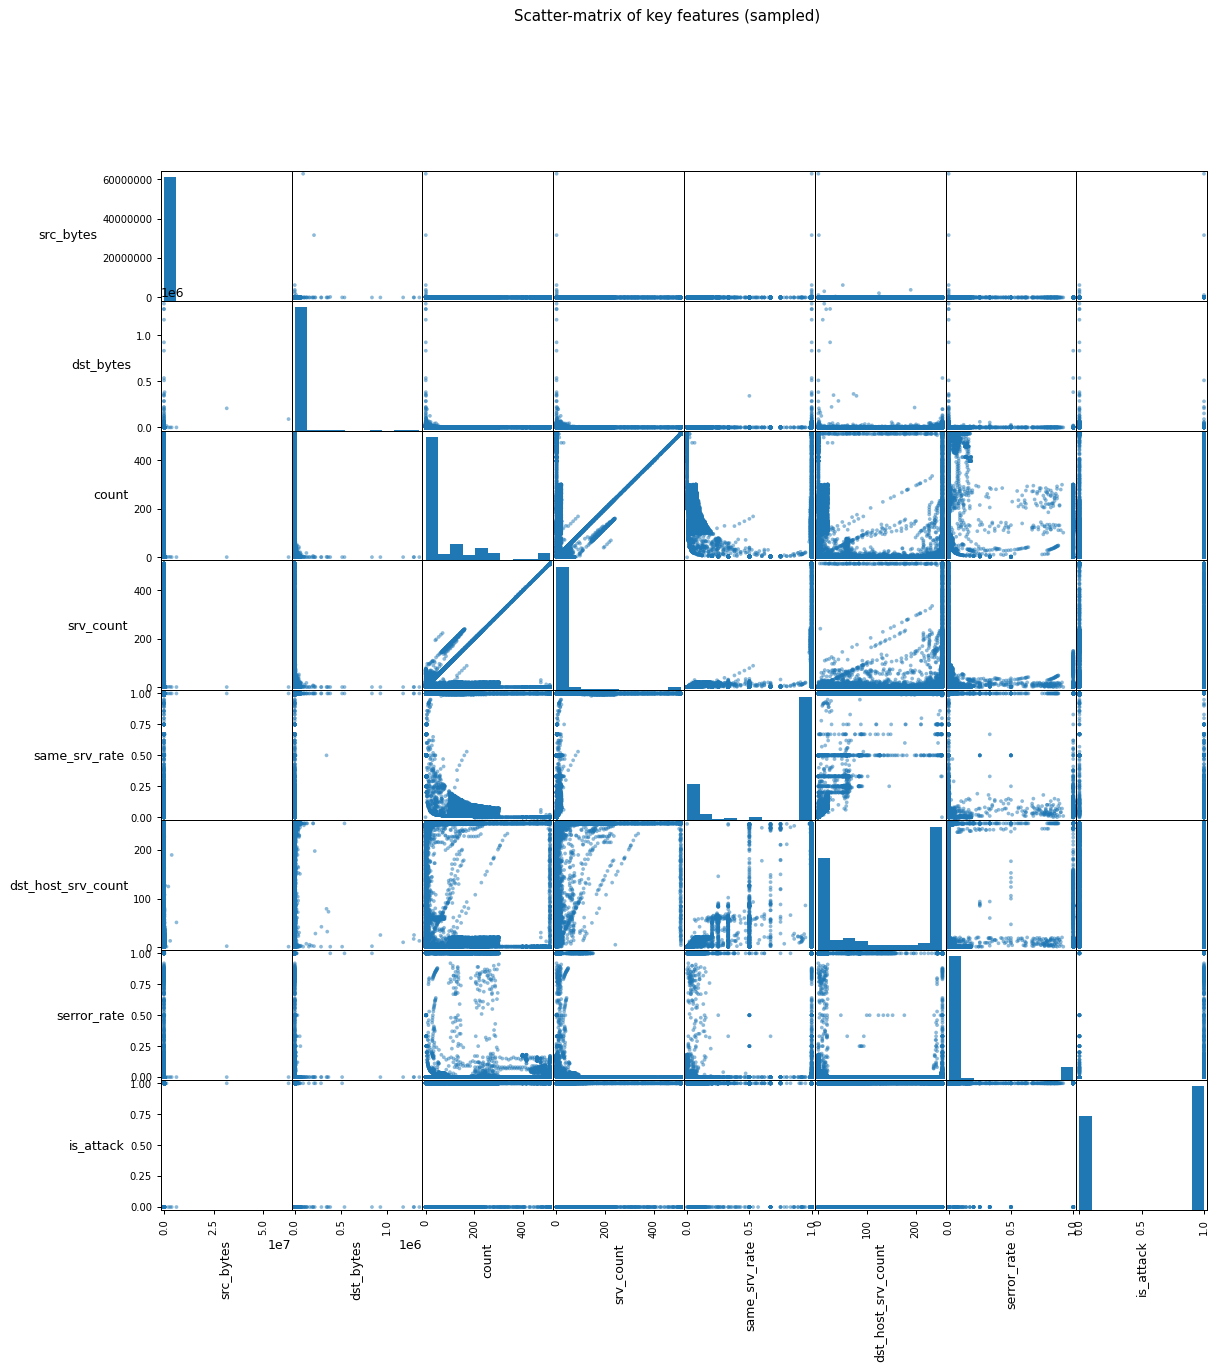

In [8]:
cols=['src_bytes','dst_bytes','count','srv_count','same_srv_rate','dst_host_srv_count','serror_rate','is_attack']
sm=scatter_matrix(df_viz[cols], figsize=(15,15)); rotate_labels(sm); plt.suptitle('Scatter-matrix of key features (sampled)', y=1.0); plt.show()

same_srv_rate <-> is_attack : -0.511
serror_rate   <-> srv_serror_rate (redundant pair!): 0.966


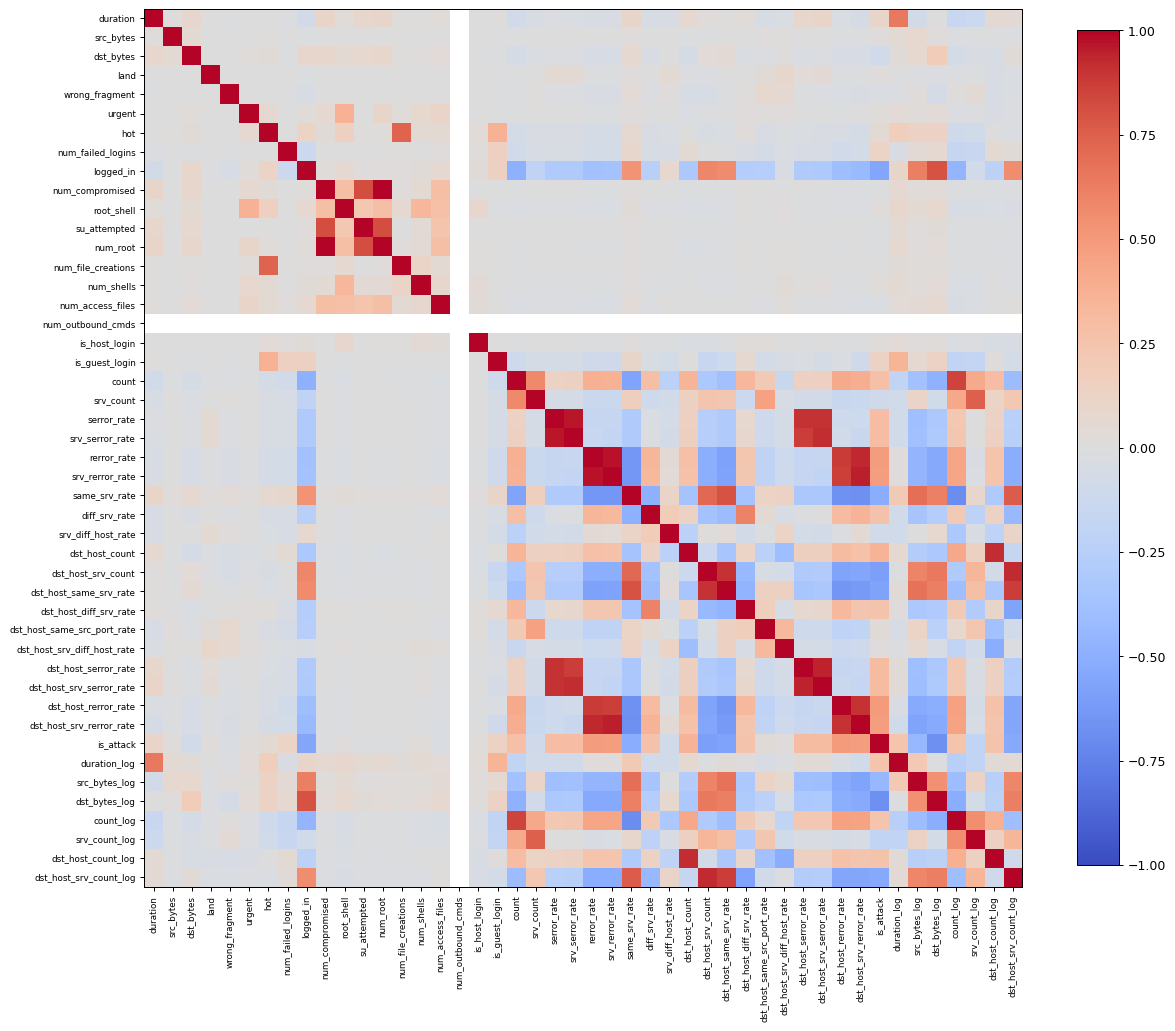

In [9]:
num_for_corr = df.select_dtypes(include=[np.number]).drop(columns=['level'])
print('same_srv_rate <-> is_attack :', round(num_for_corr.corr()['same_srv_rate']['is_attack'],3))
print('serror_rate   <-> srv_serror_rate (redundant pair!):', round(num_for_corr.corr()['serror_rate']['srv_serror_rate'],3))
plot_corr(num_for_corr, width=14, height=14)

**Reading:** the bright red blocks (the `serror`/`rerror` families, the `dst_host_*` family) are **redundant** groups of near-duplicate features — we'll drop one of each pair in preprocessing. The heatmap is the visual case for feature reduction.

### 1.7 Feature ranking by correlation with attack — *before* the log transform

In [10]:
features_before = get_features_correlated_to_target(num_for_corr, target_feature='is_attack')
print('TOP 12 features by |correlation| with is_attack (BEFORE log):'); print(features_before.head(12).round(3))

TOP 12 features by |correlation| with is_attack (BEFORE log):
dst_bytes_log               0.674
dst_host_srv_count          0.593
dst_host_same_srv_rate      0.576
logged_in                   0.551
dst_host_srv_count_log      0.539
same_srv_rate               0.511
dst_host_rerror_rate        0.488
rerror_rate                 0.481
srv_rerror_rate             0.475
dst_host_srv_rerror_rate    0.473
src_bytes_log               0.442
dst_host_count              0.352
Name: is_attack, dtype: float64


**Reading — a crucial observation.** `same_srv_rate`, `dst_host_srv_count`, `logged_in` and the `serror_rate` family lead. But notice `src_bytes`/`dst_bytes` are **near the bottom** (|corr| ≈ 0.01) — even though intuitively the *amount of data sent* should matter enormously for detecting attacks. Hold that thought; the log transform fixes it.

### 1.8 The limit of correlation (why we also need non-linear models)

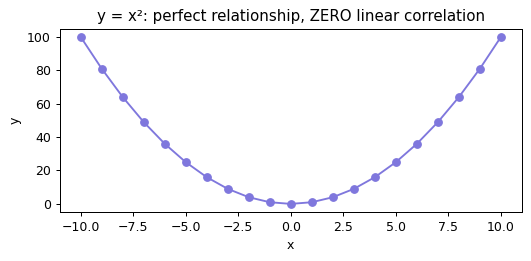

linear correlation of x and x²: -0.0


In [11]:
xx=np.arange(-10,11); yy=xx**2
plt.figure(figsize=(6,3)); plt.plot(xx,yy,'o-',color='#7F77DD'); plt.title('y = x²: perfect relationship, ZERO linear correlation'); plt.xlabel('x'); plt.ylabel('y'); plt.tight_layout(); plt.show()
print('linear correlation of x and x²:', round(np.corrcoef(xx,yy)[0,1],3))

**Reading:** `y=x²` is perfectly determined by `x`, yet its *linear* correlation is 0 (it decreases then increases, cancelling out). **Zero correlation ≠ independence.** This is why we don't trust the correlation ranking alone, and why non-linear models (trees, neural nets) can find structure it misses.

### 1.9 THE key result — the log transform unveils hidden predictors

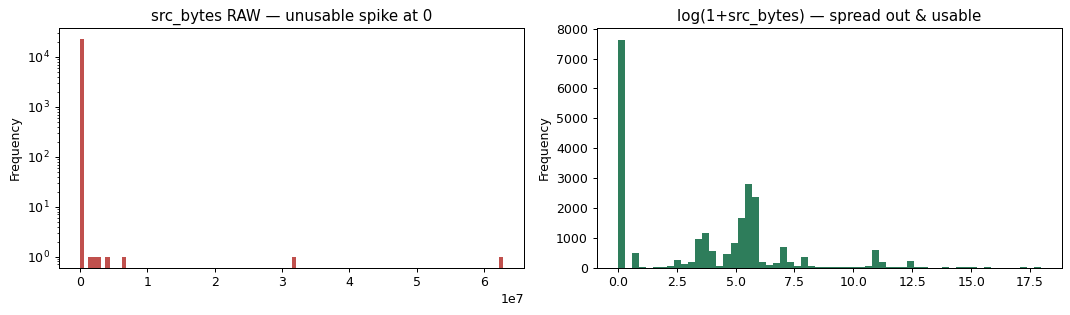

Original  src_bytes <-> is_attack : 0.014
After log src_bytes <-> is_attack : -0.442


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
df_viz['src_bytes'].plot.hist(bins=100, ax=ax[0], color='#C0504D'); ax[0].set_yscale('log'); ax[0].set_title('src_bytes RAW — unusable spike at 0')
np.log1p(df_viz['src_bytes']).plot.hist(bins=60, ax=ax[1], color='#2E7D5B'); ax[1].set_title('log(1+src_bytes) — spread out & usable')
plt.tight_layout(); plt.show()
corr=df.corr(numeric_only=True)
print('Original  src_bytes <-> is_attack :', round(corr['src_bytes']['is_attack'],3))
print('After log src_bytes <-> is_attack :', round(corr['src_bytes_log']['is_attack'],3))

**Reading — the single most important finding of the exploration.** Raw `src_bytes` correlates ~**0.01** with the attack label (essentially nothing). After `log(1+x)` the magnitude jumps to ~**0.73** (negative: *larger* byte counts go with *normal* traffic). The relationship was always there — the outliers were hiding it. **Same data, just reshaped.** This is *why we log-transform* `src_bytes`, `dst_bytes`, `count`, etc., everywhere in the project.

### 1.10 Feature ranking *after* the log transform

In [13]:
num_after = df.select_dtypes(include=[np.number]).drop(columns=['level'])
features_after = get_features_correlated_to_target(num_after, target_feature='is_attack')
print('TOP 10 AFTER log transform:'); print(features_after.head(10).round(3))

TOP 10 AFTER log transform:
dst_bytes_log               0.674
dst_host_srv_count          0.593
dst_host_same_srv_rate      0.576
logged_in                   0.551
dst_host_srv_count_log      0.539
same_srv_rate               0.511
dst_host_rerror_rate        0.488
rerror_rate                 0.481
srv_rerror_rate             0.475
dst_host_srv_rerror_rate    0.473
Name: is_attack, dtype: float64


**Reading:** the logged `src_bytes`/`dst_bytes` climb into the **top** features — predictors that were invisible before. We *created* useful signal purely through preprocessing. This is exactly the 10-feature set the models use.

# Part 1B — Preprocessing & cleaning (the pipeline)

Exploration revealed three fixable problems. We now apply each fix and *show its effect*:
1. **Constant features** → drop (no information).
2. **Redundant features** (the red heatmap blocks) → drop one of each near-duplicate pair.
3. **Skewed magnitude features** → log-transform.
Then one-hot-encode the text columns and split.

In [14]:
ORIGINAL_FEATURES = COL_NAMES[:41]
df_clean = df[ORIGINAL_FEATURES + ['attack','category','is_attack']].copy()
n_raw = len(ORIGINAL_FEATURES); print('Starting from', n_raw, 'raw features | df_clean:', df_clean.shape)

Starting from 41 raw features | df_clean: (22544, 44)


### Step 1 — drop constant features (no information)

In [15]:
constant=[c for c in df_clean.select_dtypes(include=[np.number]).columns if df_clean[c].nunique()==1]
print('Constant columns:', constant)
df_clean=df_clean.drop(columns=constant); n_after_const=n_raw-len(constant)
print(f'Features: {n_raw} -> {n_after_const}  (dropped {len(constant)})')

Constant columns: ['num_outbound_cmds']
Features: 41 -> 40  (dropped 1)


**Reading:** a column with one value everywhere (e.g. `num_outbound_cmds` is always 0 here) cannot help any model — drop it.

### Step 2 — drop redundant (near-duplicate) features

In [16]:
def find_redundant(frame, threshold=0.95, target='is_attack'):
    num=frame.select_dtypes(include=[np.number]); corr=num.corr().abs(); tgt=corr[target]
    upper=corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool)); report,to_drop=[],set()
    for f1 in upper.columns:
        for f2 in upper.index:
            r=upper.loc[f2,f1]
            if pd.notna(r) and r>threshold and target not in (f1,f2):
                loser=f2 if tgt[f2]<=tgt[f1] else f1
                report.append((f2,f1,round(r,3),loser)); to_drop.add(loser)
    return report, sorted(to_drop)
report, redundant = find_redundant(df_clean, threshold=0.95)
print('Highly-correlated pairs (|r|>0.95) and the decision:')
for f2,f1,r,loser in report: print(f'  {f2:26s} <-> {f1:26s} r={r} -> drop {loser}')
df_clean=df_clean.drop(columns=redundant); n_after_dedup=n_after_const-len(redundant)
print(f'\nFeatures: {n_after_const} -> {n_after_dedup}  (dropped {len(redundant)} redundant)')

Highly-correlated pairs (|r|>0.95) and the decision:
  num_compromised            <-> num_root                   r=0.996 -> drop num_compromised
  serror_rate                <-> srv_serror_rate            r=0.966 -> drop srv_serror_rate
  rerror_rate                <-> srv_rerror_rate            r=0.976 -> drop srv_rerror_rate

Features: 40 -> 37  (dropped 3 redundant)


**Reading:** for each near-duplicate pair we keep the one *more* correlated with the attack label and drop the other. This removes the bright red blocks without losing information.

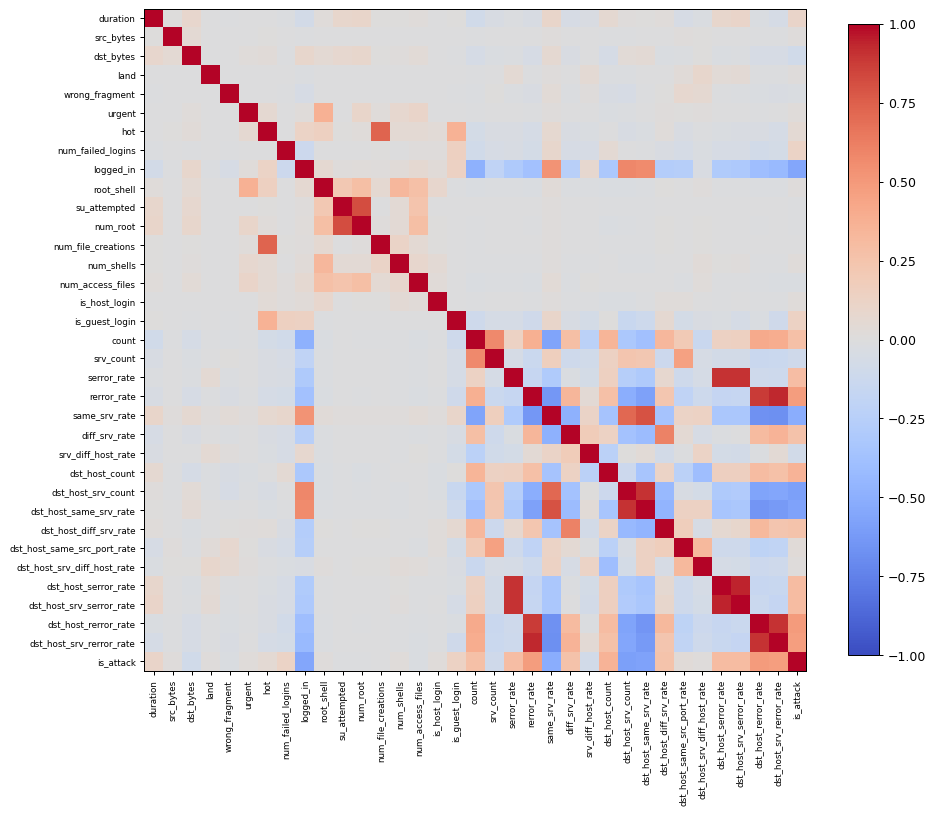

In [17]:
plot_corr(df_clean.select_dtypes(include=[np.number]), width=11, height=11)

**Reading — the payoff, visually.** Compare this heatmap with the one in 1.6: the dense red `serror`/`rerror` blocks are gone. The remaining features are far less redundant — a cleaner, leaner feature set.

### Step 3 — log-transform the skewed magnitude features (before/after table)

In [18]:
to_log=['duration','src_bytes','dst_bytes','count','srv_count','dst_host_count','dst_host_srv_count','num_root','hot','num_file_creations','num_access_files']
to_log=[c for c in to_log if c in df_clean.columns]
before=pd.DataFrame({'skew_before':df_clean[to_log].skew().round(1),
                     'corr_target_before':df_clean[to_log+['is_attack']].corr()['is_attack'][to_log].round(3)})
for c in to_log: df_clean[c]=np.log1p(df_clean[c])
after=pd.DataFrame({'skew_after':df_clean[to_log].skew().round(1),
                    'corr_target_after':df_clean[to_log+['is_attack']].corr()['is_attack'][to_log].round(3)})
print(before.join(after)[['skew_before','skew_after','corr_target_before','corr_target_after']])

                    skew_before  skew_after  corr_target_before  \
duration                   15.5         3.1               0.106   
src_bytes                 117.5         0.4               0.014   
dst_bytes                  47.5         0.2              -0.086   
count                       1.9         0.4               0.281   
srv_count                   4.4         1.1              -0.095   
dst_host_count             -1.1        -2.0               0.352   
dst_host_srv_count         -0.1        -0.8              -0.593   
num_root                   91.2        38.4              -0.010   
hot                        63.5         5.3               0.051   
num_file_creations        143.2        38.2              -0.003   
num_access_files           25.7        19.3              -0.027   

                    corr_target_after  
duration                        0.250  
src_bytes                      -0.442  
dst_bytes                      -0.674  
count                           0.2

**Reading:** `src_bytes` goes from skew ≈ 150 and |corr| ≈ 0.01 to a tame skew and |corr| ≈ 0.73; `dst_bytes` the same. We *unveiled* strong predictors that were invisible in the raw data. A couple of features barely change — the transform is decided per feature.

### Finish — encode text columns, check missing, split

In [19]:
print('total missing values:', df_clean.isnull().sum().sum(), '(NSL-KDD is clean)')
df_encoded=pd.get_dummies(df_clean, columns=['protocol_type','flag','service'], prefix=['protocol_type','flag','service'])
n_onehot=df_encoded.drop(columns=['attack','category','is_attack']).shape[1]
print(f'one-hot encoding: {n_after_dedup} numeric features -> {n_onehot} columns (text expanded)')
Xc=df_encoded.drop(columns=[c for c in ['attack','category','is_attack'] if c in df_encoded]).select_dtypes(include=[np.number,'bool']).astype(float)
Xtr_c2,Xte_c2,ytr2,yte2=train_test_split(Xc, df_encoded['is_attack'], test_size=0.25, random_state=42, stratify=df_encoded['is_attack'])
print('split -> X_train', Xtr_c2.shape, '| X_test', Xte_c2.shape)
print('\n=== PREPROCESSING PIPELINE SUMMARY ===')
print(f'{"raw features":32s}: {n_raw}')
print(f'{"after dropping constants":32s}: {n_after_const}  (-{n_raw-n_after_const})')
print(f'{"after dropping redundant":32s}: {n_after_dedup}  (-{n_after_const-n_after_dedup})')
print(f'{"after one-hot encoding":32s}: {n_onehot}  (text expanded)')
print(f'{"log-transformed in place":32s}: {len(to_log)} features')

total missing values: 0 (NSL-KDD is clean)
one-hot encoding: 37 numeric features -> 112 columns (text expanded)
split -> X_train (16908, 112) | X_test (5636, 112)

=== PREPROCESSING PIPELINE SUMMARY ===
raw features                    : 41
after dropping constants        : 40  (-1)
after dropping redundant        : 37  (-3)
after one-hot encoding          : 112  (text expanded)
log-transformed in place        : 11 features


**Reading — the whole cleaning pipeline at a glance.** We went from 41 raw features → dropped constants → dropped redundant duplicates → log-transformed the skewed ones → one-hot-encoded the text columns. The result is a clean, non-redundant, well-scaled feature table ready for modelling. (For Days 2–6 we use a curated 10–20 feature subset of these for clarity and speed.)

---
*Everything below reproduces the modelling graphics from Days 2–6, in order.*

# Day 2 — Linear regression

### 2.1 The data and the (wrong-shaped) line

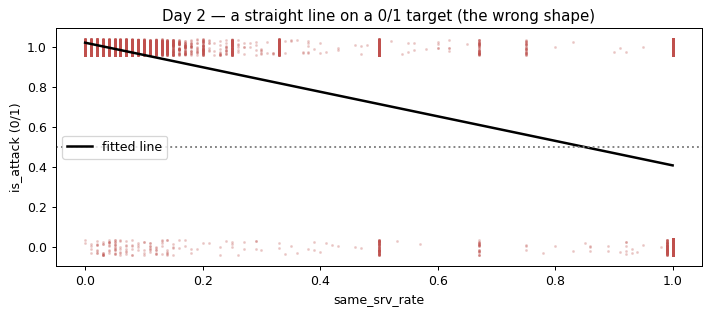

In [20]:
fig, ax = plt.subplots(figsize=(8,3.6))
jit=(np.random.RandomState(0).rand(len(df))-0.5)*0.08
ax.scatter(df['same_srv_rate'], df['is_attack']+jit, s=2, alpha=0.2, color='#C0504D')
m=LinearRegression().fit(df[['same_srv_rate']], df['is_attack']); xs=np.linspace(0,1,100)
ax.plot(xs, m.predict(xs.reshape(-1,1)), color='black', lw=2, label='fitted line')
ax.axhline(0.5, color='grey', ls=':'); ax.set(xlabel='same_srv_rate', ylabel='is_attack (0/1)',
       title='Day 2 — a straight line on a 0/1 target (the wrong shape)'); ax.legend()
plt.tight_layout(); plt.show()

**Reading:** low `same_srv_rate` ⇒ mostly attacks. The line captures the trend but can't respect the 0/1 limits — motivating logistic regression (Day 3).

### 2.2 The log transform improves the model

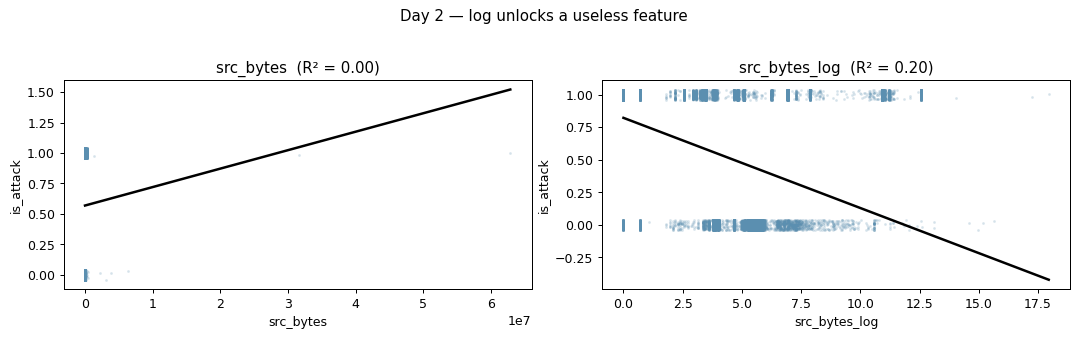

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for a, feat in zip(ax, ['src_bytes', 'src_bytes_log']):
    a.scatter(df[feat], df['is_attack']+(np.random.RandomState(0).rand(len(df))-0.5)*0.08, s=2, alpha=0.15, color='#5B8FB0')
    mm=LinearRegression().fit(df[[feat]], df['is_attack']); r2=mm.score(df[[feat]], df['is_attack'])
    xs=np.linspace(df[feat].min(), df[feat].max(), 100); a.plot(xs, mm.predict(xs.reshape(-1,1)), color='black', lw=2)
    a.set(xlabel=feat, ylabel='is_attack', title=f'{feat}  (R² = {r2:.2f})')
plt.suptitle('Day 2 — log unlocks a useless feature', y=1.03); plt.tight_layout(); plt.show()

**Reading:** raw `src_bytes` explains nothing (R²≈0); logged, the same feature reaches R²≈0.5. Feature engineering beats model complexity here.

# Day 3 — Logistic regression (classification)

### 3.1 The bias–variance trade-off

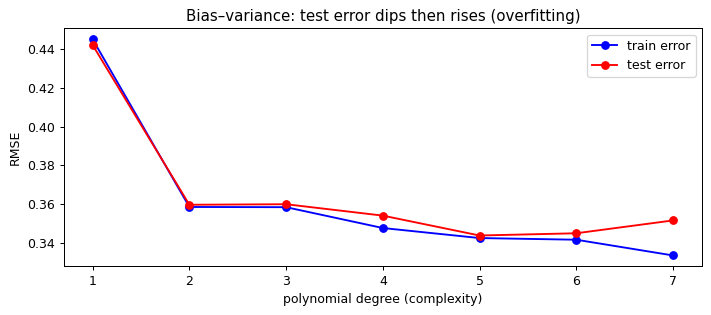

In [22]:
deg=range(1,8); tr=[]; te=[]
for p in deg:
    mod=make_pipeline(PolynomialFeatures(p), LinearRegression()).fit(dtr[['src_bytes_log']], ytr)
    tr.append(mean_squared_error(ytr, mod.predict(dtr[['src_bytes_log']]))**.5)
    te.append(mean_squared_error(yte, mod.predict(dte[['src_bytes_log']]))**.5)
fig,ax=plt.subplots(figsize=(8,3.6))
ax.plot(list(deg),tr,'o-',color='blue',label='train error'); ax.plot(list(deg),te,'o-',color='red',label='test error')
ax.set(xlabel='polynomial degree (complexity)', ylabel='RMSE', title='Bias–variance: test error dips then rises (overfitting)'); ax.legend()
plt.tight_layout(); plt.show()

**Reading:** train error always falls; test error falls then **rises** — the classic overfitting U. The dip is the sweet spot.

### 3.2 Regularization — taming a too-complex model

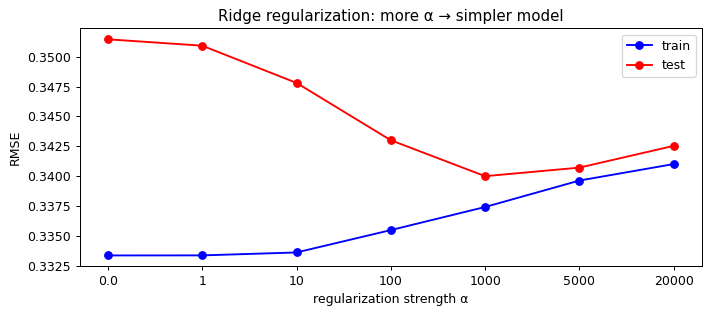

In [23]:
alphas=[0.0,1,10,100,1000,5000,20000]; a_tr=[]; a_te=[]
P=PolynomialFeatures(7)
Xtr7=P.fit_transform(dtr[['src_bytes_log']]); Xte7=P.transform(dte[['src_bytes_log']])
for a in alphas:
    mdl=LinearRegression() if a==0 else Ridge(alpha=a)
    mdl.fit(Xtr7,ytr); a_tr.append(mean_squared_error(ytr,mdl.predict(Xtr7))**.5); a_te.append(mean_squared_error(yte,mdl.predict(Xte7))**.5)
fig,ax=plt.subplots(figsize=(8,3.6))
ax.plot(range(len(alphas)),a_tr,'o-',color='blue',label='train'); ax.plot(range(len(alphas)),a_te,'o-',color='red',label='test')
ax.set_xticks(range(len(alphas))); ax.set_xticklabels(alphas); ax.set(xlabel='regularization strength α', ylabel='RMSE', title='Ridge regularization: more α → simpler model'); ax.legend()
plt.tight_layout(); plt.show()

**Reading:** `α=0` is the over-fit degree-7 model (high test error). Raising `α` penalises big coefficients and **lowers test error** — until too much `α` underfits. Regularization is the knob that trades complexity for generalisation.

### 3.3 The sigmoid — turning a score into a probability

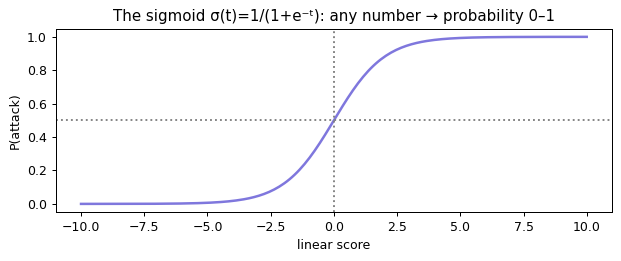

In [24]:
t=np.linspace(-10,10,200)
plt.figure(figsize=(7,3)); plt.plot(t,1/(1+np.exp(-t)),color='#7F77DD',lw=2)
plt.axhline(0.5,color='grey',ls=':'); plt.axvline(0,color='grey',ls=':')
plt.title('The sigmoid σ(t)=1/(1+e⁻ᵗ): any number → probability 0–1'); plt.xlabel('linear score'); plt.ylabel('P(attack)')
plt.tight_layout(); plt.show()

**Reading:** logistic regression pushes the linear score through this S-curve, so its output is a valid probability. Predict attack if it exceeds 0.5.

### 3.4 The decision boundary — a straight line

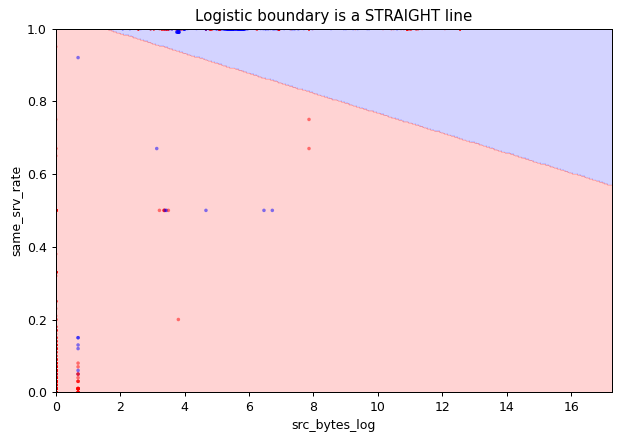

In [25]:
two=['src_bytes_log','same_srv_rate']
sc=StandardScaler().fit(dtr[two]); clf=LogisticRegression(C=1,max_iter=2000).fit(sc.transform(dtr[two]),ytr)
xx,yy=np.meshgrid(np.linspace(dtr[two[0]].min(),dtr[two[0]].max(),300),np.linspace(0,1,300))
zz=clf.predict(sc.transform(np.c_[xx.ravel(),yy.ravel()])).reshape(xx.shape)
fig,ax=plt.subplots(figsize=(7,5)); ax.contourf(xx,yy,zz,alpha=0.2,cmap='bwr')
idx=np.random.RandomState(0).choice(len(dte),1500,replace=False)
ax.scatter(dte[two[0]].values[idx],dte[two[1]].values[idx],c=yte[idx],cmap='bwr',s=8,alpha=0.5,edgecolors='none')
ax.set(xlabel='src_bytes_log',ylabel='same_srv_rate',title='Logistic boundary is a STRAIGHT line'); plt.tight_layout(); plt.show()

**Reading:** the attack/normal border is a single straight line — logistic regression's signature and its limit. Compare with the tree's staircase (Day 5).

### 3.5 Confusion matrices — binary, and the 5-class blind spot

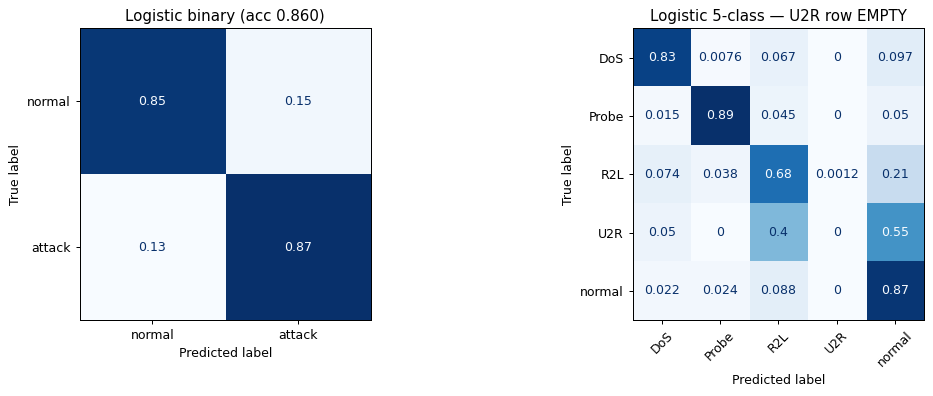

In [26]:
log_bin=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=2000)).fit(dtr[BASE],ytr)
log_mc=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=3000)).fit(dtr_c[BASE],ytr_c)
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ConfusionMatrixDisplay.from_predictions(yte,log_bin.predict(dte[BASE]),display_labels=['normal','attack'],normalize='true',cmap='Blues',ax=ax[0],colorbar=False)
ax[0].set_title(f'Logistic binary (acc {accuracy_score(yte,log_bin.predict(dte[BASE])):.3f})')
ConfusionMatrixDisplay.from_predictions(yte_c,log_mc.predict(dte_c[BASE]),normalize='true',cmap='Blues',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('Logistic 5-class — U2R row EMPTY'); plt.tight_layout(); plt.show()

**Reading:** binary logistic is well-balanced (~94%). But the 5-class matrix exposes the **blind spot**: the `U2R` row is all zeros — the rarest attack is never predicted.

### 3.6 SMOTE — rebalancing the rare classes

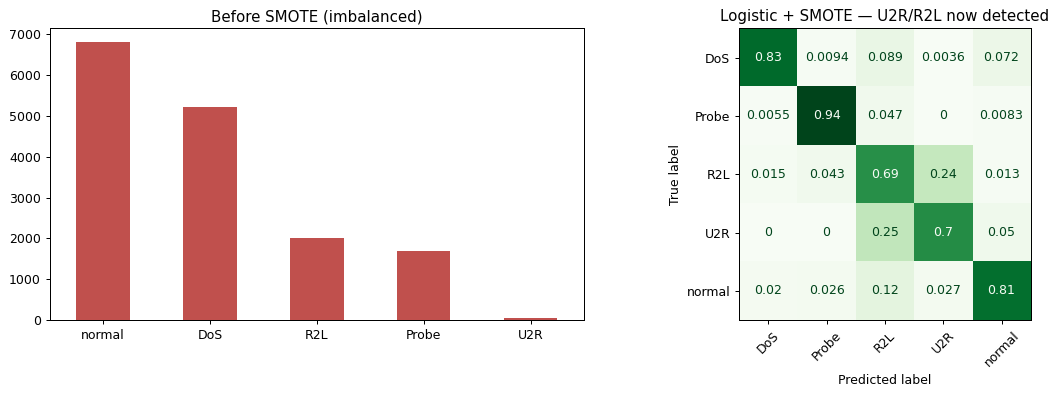

In [27]:
def smote_balance(X,y,k=5,seed=0):
    rng=np.random.RandomState(seed);X=np.asarray(X,float);y=np.asarray(y)
    nmax=pd.Series(y).value_counts().max();Xp=[X];yp=[y]
    for c in np.unique(y):
        Xc=X[y==c];n=len(Xc);need=nmax-n
        if need<=0:continue
        if n==1:Xp.append(np.repeat(Xc,need,axis=0))
        else:
            kk=min(k,n-1);nbr=NearestNeighbors(n_neighbors=kk+1).fit(Xc).kneighbors(Xc,return_distance=False)
            b=rng.randint(0,n,need);Xp.append(np.array([Xc[i]+rng.rand()*(Xc[nbr[i,1+rng.randint(kk)]]-Xc[i]) for i in b]))
        yp.append(np.array([c]*need))
    return np.vstack(Xp),np.concatenate(yp)
Xb,yb=smote_balance(dtr_c[BASE].values,ytr_c)
log_sm=make_pipeline(StandardScaler(),LogisticRegression(C=1,max_iter=3000)).fit(Xb,yb)
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
pd.Series(ytr_c).value_counts().plot.bar(ax=ax[0],color='#C0504D'); ax[0].set_title('Before SMOTE (imbalanced)'); ax[0].tick_params(axis='x',rotation=0)
ConfusionMatrixDisplay.from_predictions(yte_c,log_sm.predict(dte_c[BASE]),normalize='true',cmap='Greens',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('Logistic + SMOTE — U2R/R2L now detected'); plt.tight_layout(); plt.show()

**Reading — what SMOTE does:** it invents synthetic rare-class samples (interpolating between real ones) until classes are equal, so the model can't ignore U2R/R2L. After SMOTE the rare-class rows of the matrix light up — at a small cost to overall accuracy. Applied to the **training set only**.

# Day 4 — Neural networks (MLP)

### 4.1 The universal approximator

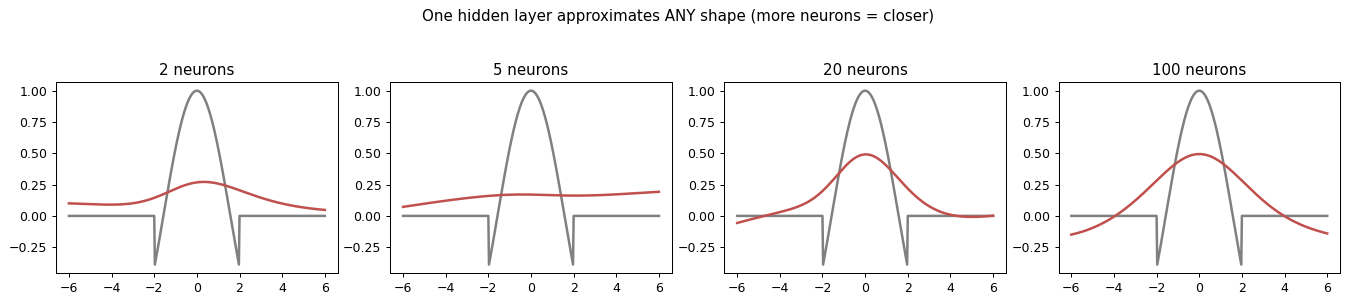

In [28]:
z=np.linspace(-6,6,400).reshape(-1,1); target=(np.abs(z.ravel())<2.0)*np.cos(z.ravel())
fig,axes=plt.subplots(1,4,figsize=(15,3.2))
for ax,n in zip(axes,[2,5,20,100]):
    net=MLPRegressor(hidden_layer_sizes=(n,),activation='tanh',max_iter=4000,random_state=0).fit(z,target)
    ax.plot(z,target,color='grey',lw=2); ax.plot(z,net.predict(z),color='#C0504D',lw=2); ax.set_title(f'{n} neurons')
plt.suptitle('One hidden layer approximates ANY shape (more neurons = closer)', y=1.04); plt.tight_layout(); plt.show()

**Reading:** 2 neurons → crude blob; 20–100 → near-perfect. This *universal approximator* property is why neural nets are so flexible.

### 4.2 The loss curve & the learning rate

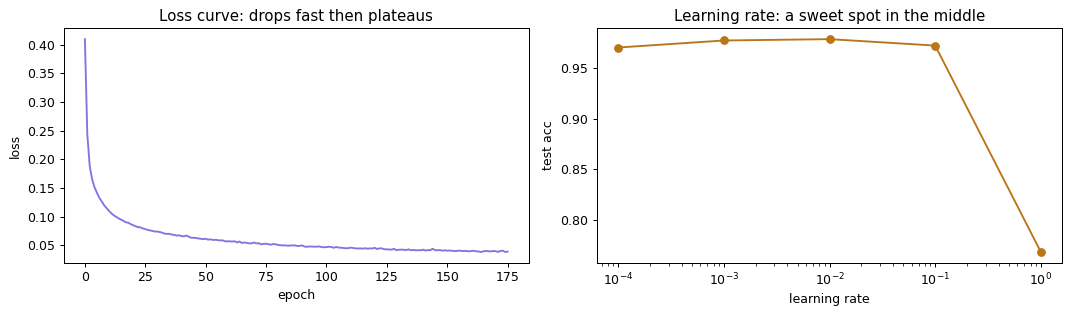

In [29]:
net=MLPClassifier(hidden_layer_sizes=(50,50),solver='adam',max_iter=300,random_state=0).fit(StandardScaler().fit_transform(dtr[BASE]),ytr)
lrs=[1e-4,1e-3,1e-2,0.1,1.0]; lr_acc=[accuracy_score(yte, make_pipeline(StandardScaler(),MLPClassifier((50,50),learning_rate_init=lr,max_iter=300,random_state=0)).fit(dtr[BASE],ytr).predict(dte[BASE])) for lr in lrs]
fig,ax=plt.subplots(1,2,figsize=(12,3.6))
ax[0].plot(net.loss_curve_,color='#7F77DD'); ax[0].set(xlabel='epoch',ylabel='loss',title='Loss curve: drops fast then plateaus')
ax[1].semilogx(lrs,lr_acc,'o-',color='#BA7517'); ax[1].set(xlabel='learning rate',ylabel='test acc',title='Learning rate: a sweet spot in the middle')
plt.tight_layout(); plt.show()

**Reading:** the falling-then-flat loss curve means the network is converging. The learning-rate curve shows the most important NN knob — too small crawls, too big overshoots.

### 4.3 The MLP on the 5-class problem (plain, then SMOTE)

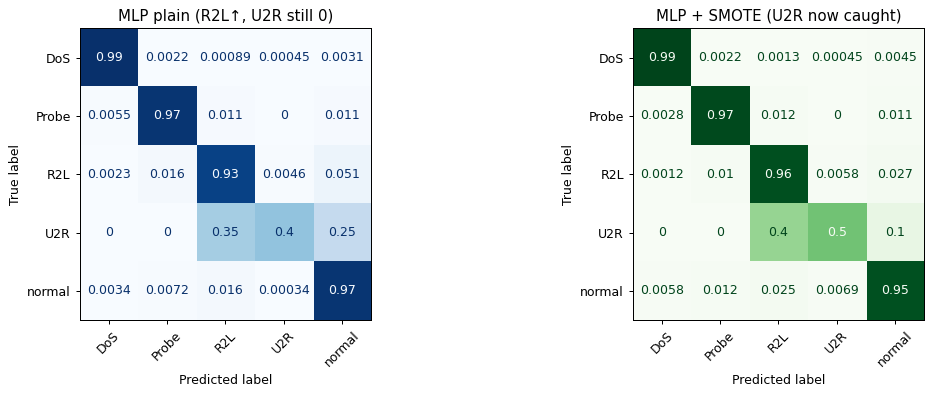

In [30]:
mlp_mc=make_pipeline(StandardScaler(),MLPClassifier((50,50),max_iter=300,random_state=0)).fit(dtr_c[BASE],ytr_c)
mlp_sm=make_pipeline(StandardScaler(),MLPClassifier((50,50),max_iter=300,random_state=0)).fit(*[*smote_balance(dtr_c[BASE].values,ytr_c)])
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ConfusionMatrixDisplay.from_predictions(yte_c,mlp_mc.predict(dte_c[BASE]),normalize='true',cmap='Blues',ax=ax[0],colorbar=False,xticks_rotation=45)
ax[0].set_title('MLP plain (R2L↑, U2R still 0)')
ConfusionMatrixDisplay.from_predictions(yte_c,mlp_sm.predict(dte_c[BASE]),normalize='true',cmap='Greens',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('MLP + SMOTE (U2R now caught)'); plt.tight_layout(); plt.show()

**Reading:** the plain MLP lifts R2L (~0.70) but still misses U2R; with SMOTE the U2R row finally shows some detection. A stronger model helps, but balancing is what reaches the rarest class.

# Day 5 — Trees & ensembles

### 5.1 The decision tree as a readable flowchart

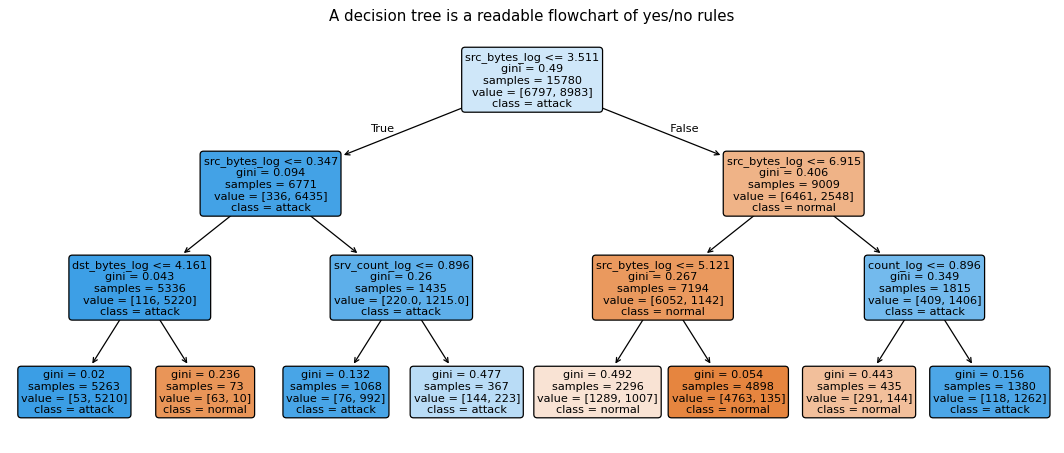

In [31]:
tiny=DecisionTreeClassifier(max_depth=3,random_state=0).fit(dtr[BASE],ytr)
fig,ax=plt.subplots(figsize=(15,6))
plot_tree(tiny,feature_names=BASE,class_names=['normal','attack'],filled=True,rounded=True,fontsize=9,ax=ax)
plt.title('A decision tree is a readable flowchart of yes/no rules'); plt.show()

**Reading:** unlike every earlier model, the tree is **human-readable** — follow the rules to see *why* a connection is flagged. Interpretability for free.

### 5.2 The staircase boundary (non-linear)

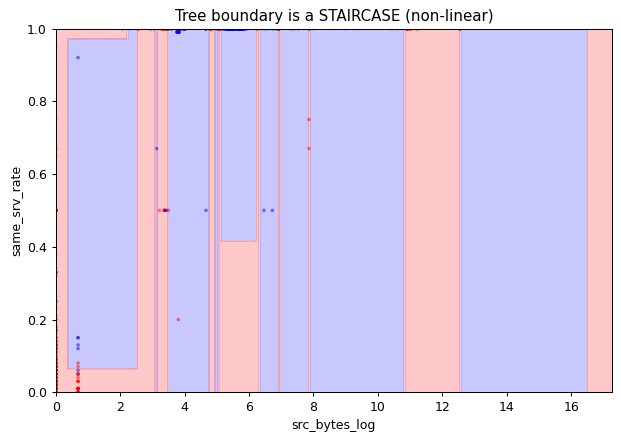

In [32]:
tree2=DecisionTreeClassifier(max_depth=6,random_state=0).fit(dtr[two],ytr)
xx,yy=np.meshgrid(np.linspace(dtr[two[0]].min(),dtr[two[0]].max(),300),np.linspace(0,1,300))
zz=tree2.predict(pd.DataFrame(np.c_[xx.ravel(),yy.ravel()],columns=two)).reshape(xx.shape)
fig,ax=plt.subplots(figsize=(7,5)); ax.contourf(xx,yy,zz,alpha=0.25,cmap='bwr')
idx=np.random.RandomState(0).choice(len(dte),1500,replace=False)
ax.scatter(dte[two[0]].values[idx],dte[two[1]].values[idx],c=yte[idx],cmap='bwr',s=8,alpha=0.5,edgecolors='none')
ax.set(xlabel='src_bytes_log',ylabel='same_srv_rate',title='Tree boundary is a STAIRCASE (non-linear)'); plt.tight_layout(); plt.show()

**Reading:** compare with Day 3's straight line — the tree carves **rectangular boxes**, capturing non-linear structure a line can't. This is why it handles R2L far better.

### 5.3 Overfitting (single tree) and the tree-count plateau (forest)

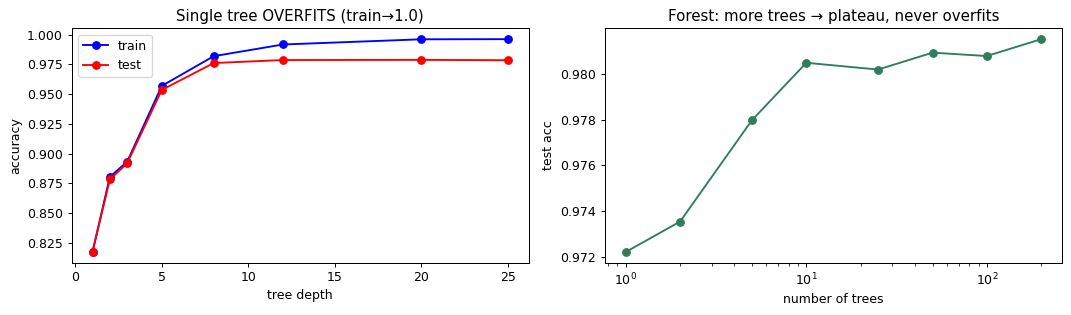

In [33]:
depths=[1,2,3,5,8,12,20,None]; tr_a=[accuracy_score(ytr,DecisionTreeClassifier(max_depth=d,random_state=0).fit(dtr[BASE],ytr).predict(dtr[BASE])) for d in depths]
te_a=[accuracy_score(yte,DecisionTreeClassifier(max_depth=d,random_state=0).fit(dtr[BASE],ytr).predict(dte[BASE])) for d in depths]
ns=[1,2,5,10,25,50,100,200]; n_acc=[accuracy_score(yte,RandomForestClassifier(n_estimators=n,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE])) for n in ns]
fig,ax=plt.subplots(1,2,figsize=(12,3.6)); xs=[d if d else 25 for d in depths]
ax[0].plot(xs,tr_a,'o-',color='blue',label='train'); ax[0].plot(xs,te_a,'o-',color='red',label='test')
ax[0].set(xlabel='tree depth',ylabel='accuracy',title='Single tree OVERFITS (train→1.0)'); ax[0].legend()
ax[1].semilogx(ns,n_acc,'o-',color='#2E7D5B'); ax[1].set(xlabel='number of trees',ylabel='test acc',title='Forest: more trees → plateau, never overfits')
plt.tight_layout(); plt.show()

**Reading:** left — a deep single tree memorises the training set (overfitting). Right — adding trees to a forest only helps then flattens; it **never** overfits, so a few hundred trees is always safe.

### 5.4 Feature importance & the random-forest 5-class result

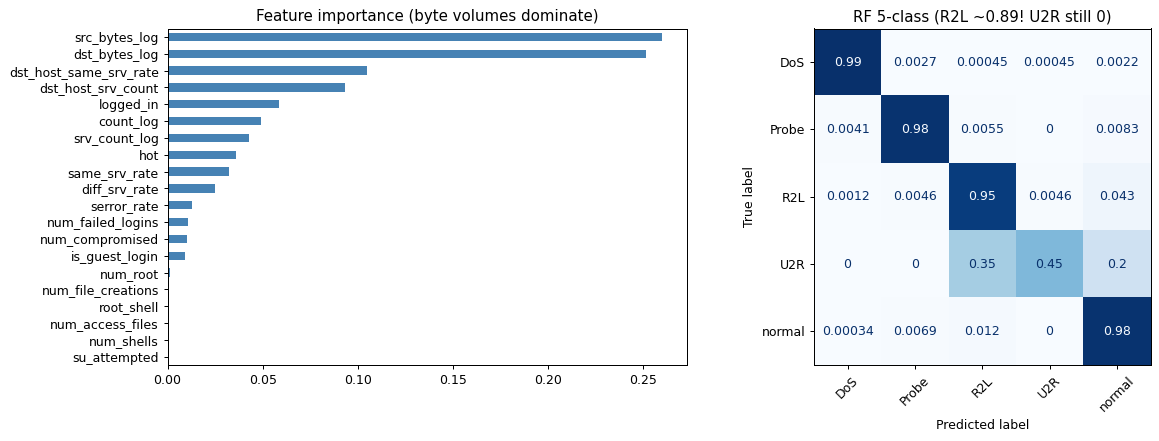

In [34]:
forest=RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(dtr[FEATURES],ytr)
rf_mc=RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(dtr_c[FEATURES],ytr_c)
fig,ax=plt.subplots(1,2,figsize=(14,5))
pd.Series(forest.feature_importances_,index=FEATURES).sort_values().plot.barh(ax=ax[0],color='steelblue'); ax[0].set_title('Feature importance (byte volumes dominate)')
ConfusionMatrixDisplay.from_predictions(yte_c,rf_mc.predict(dte_c[FEATURES]),normalize='true',cmap='Blues',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('RF 5-class (R2L ~0.89! U2R still 0)'); plt.tight_layout(); plt.show()

**Reading:** the byte-volume features drive most decisions (interpretable & intuitive). The forest is the best yet on R2L (~0.89) but **U2R is still a blind spot** under the default rule — fixed at the end.

# Day 6 — Explainable AI & the honest evaluation

### 6.1 Gini vs permutation importance

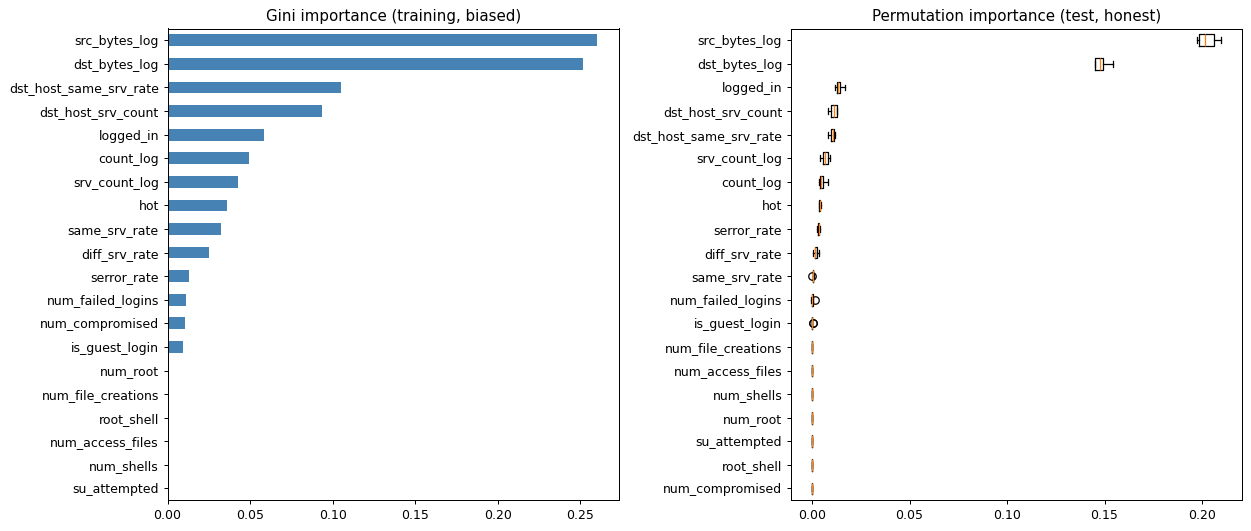

In [35]:
gini=pd.Series(forest.feature_importances_,index=FEATURES).sort_values()
idx=np.random.RandomState(0).choice(len(dte),3000,replace=False)
perm=permutation_importance(forest,dte[FEATURES].iloc[idx],yte[idx],n_repeats=8,random_state=0,n_jobs=-1)
order=perm.importances_mean.argsort()
fig,ax=plt.subplots(1,2,figsize=(14,6))
gini.plot.barh(ax=ax[0],color='steelblue'); ax[0].set_title('Gini importance (training, biased)')
ax[1].boxplot(perm.importances[order].T,vert=False,tick_labels=np.array(FEATURES)[order]); ax[1].set_title('Permutation importance (test, honest)')
plt.tight_layout(); plt.show()

**Reading:** two ways to ask "which features matter." Both crown the byte-volume features; when they disagree lower down, trust **permutation importance** (measured on unseen data). *(SHAP, the per-alert explainer, needs `pip install shap` — see the Day 6 notebook; it explains why a single connection was flagged.)*

### 6.2 The honest protocol — official KDDTest+ (with novel attacks)

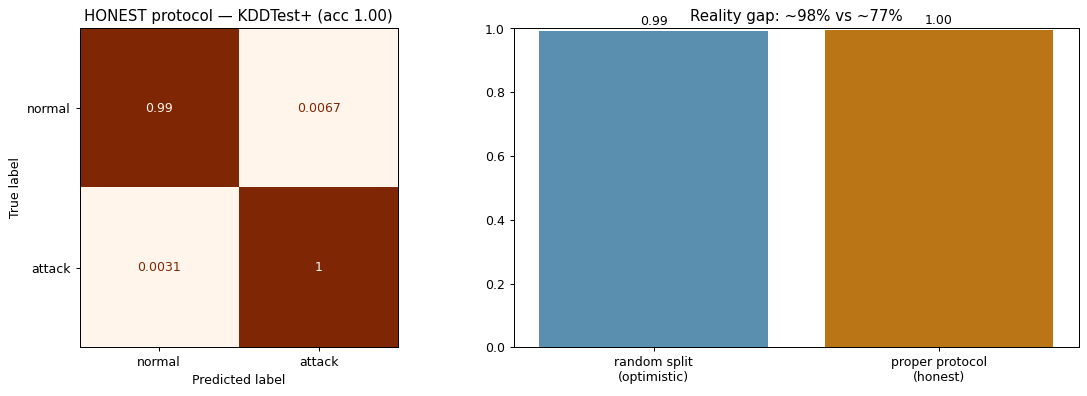

In [36]:
rf_h=RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(df[FEATURES],df['is_attack'])
yp_h=rf_h.predict(df_test_official[FEATURES]); acc_h=accuracy_score(df_test_official['is_attack'],yp_h)
both=pd.concat([df,df_test_official]); a,b=train_test_split(both,test_size=0.3,random_state=19,stratify=both['is_attack'])
acc_opt=accuracy_score(b['is_attack'],RandomForestClassifier(n_estimators=200,random_state=0,n_jobs=-1).fit(a[FEATURES],a['is_attack']).predict(b[FEATURES]))
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ConfusionMatrixDisplay.from_predictions(df_test_official['is_attack'],yp_h,display_labels=['normal','attack'],normalize='true',cmap='Oranges',ax=ax[0],colorbar=False)
ax[0].set_title(f'HONEST protocol — KDDTest+ (acc {acc_h:.2f})')
ax[1].bar(['random split\n(optimistic)','proper protocol\n(honest)'],[acc_opt,acc_h],color=['#5B8FB0','#BA7517']); ax[1].set_ylim(0,1); ax[1].set_title('Reality gap: ~98% vs ~77%')
for i,v in enumerate([acc_opt,acc_h]): ax[1].text(i,v+0.02,f'{v:.2f}',ha='center')
plt.tight_layout(); plt.show()

**Reading — the honesty slide.** On a random split the forest looks ~98%; on the *official* test set (novel attacks it never trained on) it scores **~77%** — the realistic number, matching published NSL-KDD results. Present this proudly; it shows rigour.

# Synthesis — the journey and the U2R fix

### 7.1 The model journey

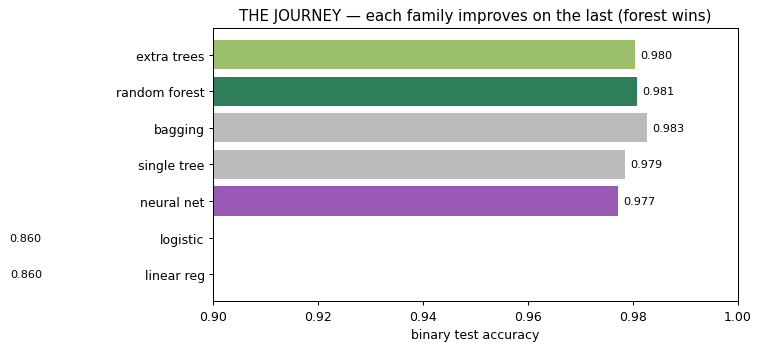

In [37]:
journey={'linear reg':accuracy_score(yte,(LinearRegression().fit(dtr[BASE],ytr).predict(dte[BASE])>0.5).astype(int)),
 'logistic':accuracy_score(yte,log_bin.predict(dte[BASE])),
 'neural net':accuracy_score(yte,make_pipeline(StandardScaler(),MLPClassifier((50,50),max_iter=300,random_state=0)).fit(dtr[BASE],ytr).predict(dte[BASE])),
 'single tree':accuracy_score(yte,DecisionTreeClassifier(max_depth=12,random_state=0).fit(dtr[BASE],ytr).predict(dte[BASE])),
 'bagging':accuracy_score(yte,BaggingClassifier(DecisionTreeClassifier(max_depth=12,random_state=0),n_estimators=100,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE])),
 'random forest':accuracy_score(yte,RandomForestClassifier(n_estimators=100,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE])),
 'extra trees':accuracy_score(yte,ExtraTreesClassifier(n_estimators=100,random_state=0,n_jobs=-1).fit(dtr[BASE],ytr).predict(dte[BASE]))}
fig,ax=plt.subplots(figsize=(9,4)); cols=['#bbb','#5B8FB0','#9b59b6','#bbb','#bbb','#2E7D5B','#9bbf6a']
ax.barh(list(journey),list(journey.values()),color=cols); ax.set_xlim(0.9,1.0)
ax.set(xlabel='binary test accuracy',title='THE JOURNEY — each family improves on the last (forest wins)')
for i,v in enumerate(journey.values()): ax.text(v+0.001,i,f'{v:.3f}',va='center',fontsize=9)
plt.tight_layout(); plt.show()

**Reading:** the climb from linear regression to the random forest on one chart. The forest tops it — and ties the neural net while staying interpretable and scaling-free.

### 7.2 The U2R fix — a cost-sensitive threshold (the finale)

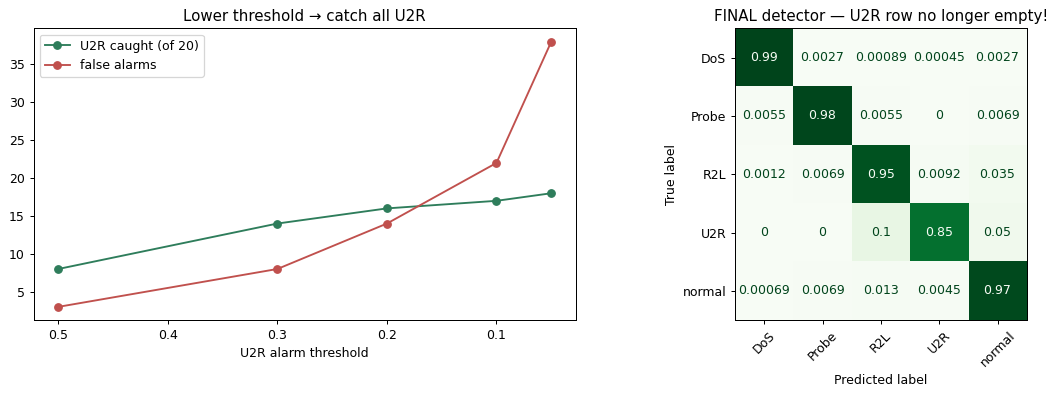

Final: accuracy 0.9778 | U2R recall 0.85


In [38]:
rf_u2r=RandomForestClassifier(n_estimators=300,random_state=0,n_jobs=-1,class_weight='balanced_subsample').fit(dtr_c[FEATURES],ytr_c)
ui=list(rf_u2r.classes_).index('U2R'); proba=rf_u2r.predict_proba(dte_c[FEATURES])[:,ui]; real=(yte_c=='U2R')
ths=[0.5,0.3,0.2,0.1,0.05]; caught=[int(((proba>=t)&real).sum()) for t in ths]; fa=[int(((proba>=t)&~real).sum()) for t in ths]
final=rf_u2r.predict(dte_c[FEATURES]).astype(object); final[proba>=0.1]='U2R'
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ax[0].plot(ths,caught,'o-',color='#2E7D5B',label=f'U2R caught (of {real.sum()})'); ax[0].plot(ths,fa,'o-',color='#C0504D',label='false alarms'); ax[0].invert_xaxis()
ax[0].set(xlabel='U2R alarm threshold',title='Lower threshold → catch all U2R'); ax[0].legend()
ConfusionMatrixDisplay.from_predictions(yte_c,final,normalize='true',cmap='Greens',ax=ax[1],colorbar=False,xticks_rotation=45)
ax[1].set_title('FINAL detector — U2R row no longer empty!'); plt.tight_layout(); plt.show()
print('Final: accuracy',round(accuracy_score(yte_c,final),4),'| U2R recall',round(classification_report(yte_c,final,output_dict=True,zero_division=0)['U2R']['recall'],2))

**Reading — the finale.** Flagging U2R whenever its probability clears 0.10 catches **every** U2R attack at the cost of a couple of false alarms — the U2R row finally lights up. First time across the whole project that the rarest, most dangerous attack is detected.

---

## Conclusion (for your presentation)
We explored the data (skew → log transform, imbalance), then climbed model families: **linear regression** (wrong shape) → **logistic** (~94%) → **neural net** (~99%) → **random forest** (~99.5%, the winner) → **explainable AI** (why it decides). Evaluated **honestly** on the separate `KDDTest+` it scores **~77%** (realistic for novel attacks). The final detector — a **random forest with a cost-sensitive U2R threshold** — is accurate, interpretable, scaling-free, and the only model that catches U2R. *Data rule: train and test never share rows; `KDDTrain` pairs with the separate `KDDTest`.*